In [10]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h0 = args['h0']
    w = args['omega']
    return h0 * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -(4 * Jvalue / dim_spin) * Sz2

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx

    return H0, H1, Sx, Sz 

In [11]:
def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, Sx, Sz  = h0_ham_lmg(N, Jvalue)

    # time-dependent Hamiltonian
    H_td = [H0 , [H1, h_t]]

    # initial state (fully polarized + vacuum)
    S = N / 2
    psi_spin = basis(int(2*S + 1), 0)

    # evolve
    result = mesolve(H_td,psi_spin,tlist,[],[Sx / N, Sz / N],args=args)

    op_Sx_avg = np.average(result.expect[0])
    op_Sz_avg = np.average(result.expect[1])

    return op_Sx_avg, op_Sz_avg

100%|██████████| 50/50 [00:02<00:00, 17.79it/s]


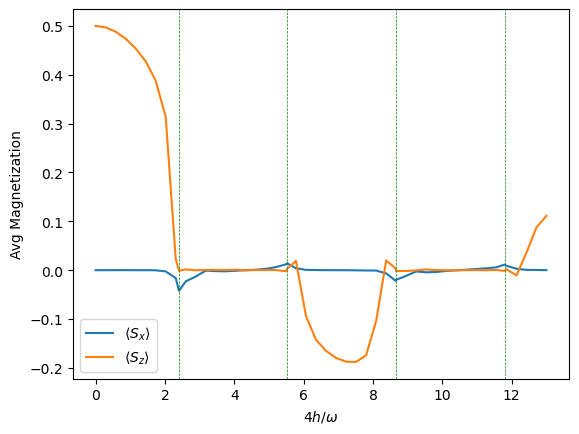

In [12]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
omega0 = 2
Jvalue = 1
g = 0

omega = 20

h0s = np.linspace(0, 13, 46) * omega / 4
h0s = np.sort(np.append(h0s, frz * omega / 4))

# time
ttop = 100
tlist = np.linspace(0, ttop, ttop * 20 + 1)

args_list = [{
    'omega': omega,
    'h0': h0,
    'g': g,
    'tlist': tlist,
    'N': N,
    'hbar': hbar,
    'omega0': omega0,
    'Jvalue': Jvalue
} for h0 in h0s]

# parallel run
p = Pool(processes=4)
results = p.map(run_dynamics_lmg, tqdm(args_list))

results = np.array(results)
Sx_avgs = results[:, 0]
Sz_avgs = results[:, 1]

# plot
plt.plot(4*h0s/omega, Sx_avgs, label=r'$\langle S_x \rangle$')
plt.plot(4*h0s/omega, Sz_avgs, label=r'$\langle S_z \rangle$')

for i in frz:
    plt.axvline(x=i, ls='--', color='green', lw=0.5)

plt.xlabel(r'$4h / \omega$')
plt.ylabel('Avg Magnetization')
plt.legend()
plt.show()

# Initial state


In [1]:
from qutip import *
import numpy as np
from scipy.special import jn_zeros

# -----------------------------
# time-dependent drive
# -----------------------------
def h_t(t, args):
    h0 = args['h0']
    w = args['omega']
    return h0 * np.cos(w * t)

# -----------------------------
# LMG Hamiltonian pieces
# -----------------------------
def h0_ham_lmg(N, Jvalue):

    S = N / 2

    # collective spin operators
    Sx = jmat(S, 'x')
    Sz = jmat(S, 'z')
    Sz2 = Sz * Sz

    dim_spin = int(2*S + 1)
    I_spin = qeye(dim_spin)

    # -------- Hamiltonian parts --------

    # LMG interaction
    H0 = -(4 * Jvalue / dim_spin) * Sz2

    # transverse field (time-dependent part will multiply this)
    H1 = 2 * Sx

    return H0, H1, Sx, Sz 

In [2]:
def run_dynamics_lmg(args):

    tlist = args['tlist']
    N = args['N']
    g = args['g']
    hbar = args['hbar']
    omega0 = args['omega0']
    Jvalue = args['Jvalue']

    H0, H1, Sx, Sz  = h0_ham_lmg(N, Jvalue)

    en,st = Sz.eigenstates()
    
    idx = np.argmin(np.abs(en - 1))
    psi0 = st[idx]


    # time-dependent Hamiltonian
    H_td = [H0 , [H1, h_t]]

    # initial state (fully polarized + vacuum)
    S = N / 2
    psi_spin = psi0

    # evolve
    result = mesolve(H_td,psi_spin,tlist,[],[Sx / N, Sz / N],args=args)

    op_Sx_avg = np.average(result.expect[0])
    op_Sz_avg = np.average(result.expect[1])

    return op_Sx_avg, op_Sz_avg

100%|██████████| 50/50 [00:03<00:00, 15.77it/s]


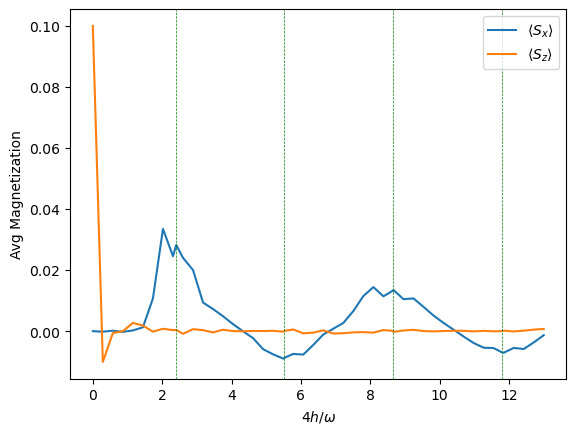

In [3]:
import matplotlib.pyplot as plt
from multiprocessing import Pool
from tqdm import tqdm

# freezing points
frz = jn_zeros(0, 4)

# parameters
N = 10
hbar = 1.0
omega0 = 2
Jvalue = 1
g = 0

omega = 20

h0s = np.linspace(0, 13, 46) * omega / 4
h0s = np.sort(np.append(h0s, frz * omega / 4))

# time
ttop = 100
tlist = np.linspace(0, ttop, ttop * 20 + 1)

args_list = [{
    'omega': omega,
    'h0': h0,
    'g': g,
    'tlist': tlist,
    'N': N,
    'hbar': hbar,
    'omega0': omega0,
    'Jvalue': Jvalue
} for h0 in h0s]

# parallel run
p = Pool(processes=4)
results = p.map(run_dynamics_lmg, tqdm(args_list))

results = np.array(results)
Sx_avgs = results[:, 0]
Sz_avgs = results[:, 1]

# plot
plt.plot(4*h0s/omega, Sx_avgs, label=r'$\langle S_x \rangle$')
plt.plot(4*h0s/omega, Sz_avgs, label=r'$\langle S_z \rangle$')

for i in frz:
    plt.axvline(x=i, ls='--', color='green', lw=0.5)

plt.xlabel(r'$4h / \omega$')
plt.ylabel('Avg Magnetization')
plt.legend()
plt.show()